# CITS4012 — PIQA main model

The main model, the data preparation and the hyperparameter study are all
finished here.
The attention section is built in but has not been explored yet

### How to read this file

Every cell title starts with one of these:

| tag | meaning |
|---|---|
| `[RUN]` | run it, every time you open the notebook |
| `[RUN ONCE]` | run it once per session, it takes a few minutes |
| `[DONE]` | already run, results are written underneath — **do not re-run**|
| `[TO DO]` | not run yet, somebody still has to do this |

### Protocol — please keep these the same, or the numbers cannot be compared

* split: `train_test_split(test_size=0.15, random_state=0, stratify=label)` -> 13,696 / 2,417
* **the test set is not touched until 13 October**
* 3 seeds per configuration, report mean +/- sd
* 15 epochs for every run (the model improves slowly until epoch 12)
* pooled seed sd is about 0.004, so **a gap below 0.008 is not a real gap**

---
# PART 0 — Setup

In [15]:
# @title [RUN] Environment set-up
import json
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

cuda


In [16]:
# @title [RUN] Download the PIQA data from Drive
# the four PIQA files are zipped together on Drive, shared as "anyone with the link"
# so this works on any Colab account without uploading anything

piqa_data_id = "1g38leqF4Z_9_rOKvfMsStgLNO0yabfH5"
!gdown -q $piqa_data_id -O piqa_data.zip
!unzip -q -o piqa_data.zip

import os
for file_name in ["train.jsonl", "train-labels.lst", "test.jsonl", "test-labels.lst"]:
    print(file_name, os.path.getsize(file_name), "bytes")


train.jsonl 4382162 bytes
train-labels.lst 32226 bytes
test.jsonl 495929 bytes
test-labels.lst 3676 bytes


---
# PART 1 — Data preparation

Nothing here needs changing. Run it all once and move on.

In [17]:
# @title [RUN] Step 1: Text processing and reading the data

# clean_str -> taken from A1
def clean_str(string):
    string = re.sub(r"[^A-Za-z0-9,!?\']", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\s{2,}", " ", string)
    return string.strip().lower()

def word_set(string):
    return set(clean_str(string).split())

# read one split into a flat list of rows ---------------------------------------
# structure -> [{'goal':.., 'sol1':.., 'sol2':.., 'label':0/1}]
# label 0 means sol1 is the correct one, label 1 means sol2
def read_piqa(data_path, label_path):
    rows = []
    data_line = open(data_path).readlines() # read JSON texts
    label_line = open(label_path).readlines() # read 0/1

    for line, lab in zip(data_line, label_line): # zip -> match the two files
        if lab.strip() == "": # skip empty lines
            continue
        d = json.loads(line) # JASON to dic
        row = {}
        row["goal"]  = d["goal"]
        row["sol1"]  = d["sol1"]
        row["sol2"]  = d["sol2"]
        row["label"] = int(lab.strip()) # from a different file. '1\n' -> 1 (int)
        rows.append(row)
    return rows
    # structure of rows
    # rows = [{'goal':'xxx', ..., "sol2":"xxx", "label":1}, {question}, {question}]

data_train_rows = read_piqa("train.jsonl", "train-labels.lst")
data_test_rows  = read_piqa("test.jsonl", "test-labels.lst")

print("train rows:", len(data_train_rows))
print("test rows :", len(data_test_rows))
print("") # Test
for r in data_train_rows[:2]:
    print("goal :", r["goal"])
    print("sol1 :", r["sol1"][:90])
    print("sol2 :", r["sol2"][:90])
    print("label:", r["label"])
    print("")

# train rows: 16113
# test rows : 1838

train rows: 16113
test rows : 1838

goal : When boiling butter, when it's ready, you can
sol1 : Pour it onto a plate
sol2 : Pour it into a jar
label: 1

goal : To permanently attach metal legs to a chair, you can
sol1 : Weld the metal together to get it to stay firmly in place
sol2 : Nail the metal together to get it to stay firmly in place
label: 0



In [18]:
# @title [RUN] Step 2: Data description table

def describe_data(rows, name):
    # one list per statistic -> fill them row by row, then average at the end
    goal_length     = []
    sol_length      = []
    label_list      = []
    jaccard         = []
    different_words = []

    for r in rows:
        goal_length.append(len(r["goal"].split()))

        # take the longer of the two solutions -> maxlength has to fit both
        sol_length.append(max(len(r["sol1"].split()), len(r["sol2"].split())))

        label_list.append(r["label"])

        # [how similar are the two solutions]----------------------------------
        # this is the whole difficulty of PIQA -> the two options are almost the same sentence
        a = word_set(r["sol1"])
        b = word_set(r["sol2"])

        # jaccard = shared words / all words -> 1 means identical, 0 means nothing in common
        jaccard.append(len(a & b) / len(a | b))

        # symmetric difference -> how many words are in one solution but not the other
        different_words.append(len(a ^ b))

    # [pack into one dict]-----------------------------------------------------
    output_row = {}
    output_row["set"]                  = name
    output_row["rows"]                 = len(rows)
    output_row["label=1 rate"]         = round(np.mean(label_list), 3)
    output_row["goal words"]           = round(np.mean(goal_length), 1)
    output_row["p95 goal words"]       = round(np.percentile(goal_length, 95))
    output_row["solution words"]       = round(np.mean(sol_length), 1)
    output_row["p95 sol words"]        = round(np.percentile(sol_length, 95))
    output_row["sol1 vs sol2 overlap"] = round(np.mean(jaccard), 3)
    output_row["different words"]      = round(np.mean(different_words), 1)
    return output_row


output_table = []
output_table.append(describe_data(data_train_rows, "training set"))

print("")
print("+++ PIQA Data +++")
print(pd.DataFrame(output_table).set_index("set").T.to_markdown())


+++ PIQA Data +++
|                      |   training set |
|:---------------------|---------------:|
| rows                 |      16113     |
| label=1 rate         |          0.5   |
| goal words           |          7.1   |
| p95 goal words       |         13     |
| solution words       |         19.4   |
| p95 sol words        |         54     |
| sol1 vs sol2 overlap |          0.654 |
| different words      |          5.4   |


In [19]:
# @title [RUN] Step 3: Split the training set

# PIQA rows are independent of each other, so a plain stratified split is fine.
# random_state is fixed so that everybody gets the same split -> numbers stay comparable.

all_label = [r["label"] for r in data_train_rows]
train_part1, train_part2 = train_test_split(data_train_rows, test_size=0.15,
                                            random_state=0, stratify=all_label)
# validation set: 15%
# random_state = 0 -> same seed for everyone
# strategy = all_label -> 50 / 50 split for sol 1 and sol 2 in the training set and val set

print("part1 (train) rows", len(train_part1))
print("part2 (val)   rows", len(train_part2))
print("test          rows", len(data_test_rows))
print("")
print("label=1 rate -> part1 %.3f, part2 %.3f" % (np.mean([r["label"] for r in train_part1]),
                                                  np.mean([r["label"] for r in train_part2])))

#part1 (train) rows 13696
#part2 (val)   rows 2417
#test          rows 1838
#label=1 rate -> part1 0.500, part2 0.500

part1 (train) rows 13696
part2 (val)   rows 2417
test          rows 1838

label=1 rate -> part1 0.500, part2 0.500


In [20]:
# @title [RUN] Step 4: Vocabulary and make_batch_input

# same idea as A1 -> pre-allocate np.zeros and write into it.
# the vectors are made inside the model by nn.Embedding, so here we only store the index.

maxgoal = 20   # -> p95 goal words: 13
maxsol  = 60   # -> p95 sol words: 54


def build_vocabulary(rows, min_count=2): # remove if word appears less than 2 times
    # built from the TRAINING part only, not from validation or test
    word_count = Counter() # each word appears how many times
    for r in rows:
        word_count.update(clean_str(r["goal"]).split())
        word_count.update(clean_str(r["sol1"]).split())
        word_count.update(clean_str(r["sol2"]).split())

    vocabulary = {"<pad>": 0, "<unk>": 1} # 0 and 1 are reserved -> 0 for padding, 1 for unknown
    for word, n in word_count.most_common():
        if n >= min_count:
            vocabulary[word] = len(vocabulary) # next free number
    return vocabulary
    # shape of vocabulary: a dict with 11488 entries -> {'<pad>':0, '<unk>':1, 'the':2, 'a':3, ...}


def words_to_index(word_list, vocabulary, maxlength):
    index_list = np.zeros(maxlength, dtype=np.int64) # initiate with all 0s
    for i, w in enumerate(word_list):
        if i == maxlength:
            break # cut off if longer than maxlength
        if w in vocabulary:
            index_list[i] = vocabulary[w]
        else:
            index_list[i] = 1                      # Assign to 1 if unknown
    return index_list
    # shape of index_list:['weld','the','metal'] becomes [847, 2, 311, 0, 0, ... 0]


def make_batch_input(rows, vocabulary):
    n = len(rows)
    goal_index = np.zeros((n, maxgoal), dtype=np.int64)
    sol1_index = np.zeros((n, maxsol), dtype=np.int64)
    sol2_index = np.zeros((n, maxsol), dtype=np.int64)
    label      = np.zeros(n, dtype=np.int64)

    for i, r in enumerate(rows):
        goal_index[i] = words_to_index(clean_str(r["goal"]).split(), vocabulary, maxgoal)
        sol1_index[i] = words_to_index(clean_str(r["sol1"]).split(), vocabulary, maxsol)
        sol2_index[i] = words_to_index(clean_str(r["sol2"]).split(), vocabulary, maxsol)
        label[i]      = r["label"]

    return goal_index, sol1_index, sol2_index, label
    # goal_index  (13696, 20)
    # sol1_index  (13696, 60)
    # sol2_index  (13696, 60)
    # label       (13696,)
    # "word, word, word, word" -> [ 5, 10, 15, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0 ]


vocabulary = build_vocabulary(train_part1, min_count=2)
print("vocabulary size:", len(vocabulary))

train_part1_input = make_batch_input(train_part1, vocabulary)
train_part2_input = make_batch_input(train_part2, vocabulary)
test_input        = make_batch_input(data_test_rows, vocabulary)


vocabulary size: 11488


In [21]:
# @title [RUN] Step 5: Dumb baselines -> the floor [VIKA TO REPLACE BASELINE ANALYSIS]

# 50% is NOT the bar to beat. A word-overlap rule already gets 0.5259, so that is the number
# every model has to beat before it is worth anything. Same role as the TF-IDF baseline in A1.

part2_gold = train_part2_input[3]

def accuracy(predicted, gold):
    return np.mean(np.array(predicted) == np.array(gold))


# baseline 1 -> always pick sol2
b1 = accuracy(np.ones(len(train_part2), dtype=np.int64), part2_gold)

# baseline 2 -> pick the longer solution
predicted = []
for r in train_part2:
    if len(r["sol2"].split()) > len(r["sol1"].split()):
        predicted.append(1)
    else:
        predicted.append(0)
b2 = accuracy(predicted, part2_gold)

# baseline 3 -> pick the solution that shares more of its words with the goal
predicted = []
for r in train_part2:
    g = word_set(r["goal"])
    o1 = len(g & word_set(r["sol1"])) / max(1, len(word_set(r["sol1"])))
    o2 = len(g & word_set(r["sol2"])) / max(1, len(word_set(r["sol2"])))
    if o2 > o1:
        predicted.append(1)
    else:
        predicted.append(0)
b3 = accuracy(predicted, part2_gold)

output_table = []
output_table.append({"baseline": "always sol2",            "accuracy": round(b1, 4)})
output_table.append({"baseline": "longer solution",        "accuracy": round(b2, 4)})
output_table.append({"baseline": "more overlap with goal", "accuracy": round(b3, 4)})

print("")
print("+++ Baselines (validation) +++")
print(pd.DataFrame(output_table).to_markdown(index=False))

floor = max(b1, b2, b3)
print("")
print("floor to beat -> %.4f" % floor)



+++ Baselines (validation) +++
| baseline               |   accuracy |
|:-----------------------|-----------:|
| always sol2            |     0.5002 |
| longer solution        |     0.4841 |
| more overlap with goal |     0.5259 |

floor to beat -> 0.5259


---
# PART 2 — Attention

**This is the section Ray takes over.** The three attention mechanisms are written as three
plain functions, on purpose, so that they can be edited without touching the model class.

All three do exactly the same three steps:

```
1.  score   compare a query against a list of vectors   ->  one number per vector
2.  alpha   softmax the scores                          ->  weights that add up to 1
3.  output  weighted average using alpha
```

They only differ in **what gets scored** and **where the query comes from**:

| | what gets scored | query comes from | learnable params |
|---|---|---|---|
| `attention_on_solution` | the 60 solution words | the goal, or a trained vector | 40,000 (goal mode) / 200 (self mode) |
| `attention_on_goal` | the 20 goal words | a trained vector | 200 |
| `cross_attention` | one solution against the other | no query at all | 0 |

**Every function returns `(result, weights)`.** The weights are what you plot in a heat map,
so never drop them.

In [22]:
# @title [RUN] Step 6: The three attention functions   <-- RAY to adjust if needed

# ---------------------------------------------------------------------------------
# helper: squeeze a sequence of word vectors into ONE vector, ignoring the padding
# this is the "no attention" option -> every real word gets the same weight
# ---------------------------------------------------------------------------------
def masked_pool(rnn_output, index, pooling="mean"):
    # rnn_output -> (B, L, 2H)      index -> (B, L), 0 means padding
    mask = (index != 0).float().unsqueeze(2)
    if pooling == "max":
        rnn_output = rnn_output.masked_fill(mask == 0, -1e9)
        return rnn_output.max(dim=1)[0]
    total = (rnn_output * mask).sum(dim=1)
    count = mask.sum(dim=1).clamp(min=1.0)
    return total / count


# ---------------------------------------------------------------------------------
# (1) ATTENTION ON THE SOLUTION
#     picks the important words inside ONE solution
#
#     query comes from outside:
#        goal mode -> query = W * goal_vector      (W is a Linear(200,200) in the model)
#        self mode -> query = a trained vector     (pool_query in the model)
#
#     returns -> context (B, 2H)   and   alpha (B, 60)   <- alpha is the heat map
# ---------------------------------------------------------------------------------
def attention_on_solution(solution_output, solution_index, query):
    # solution_output -> (B, 60, 2H)   query -> (B, 2H) or (2H,)
    if query.dim() == 1:
        score = torch.matmul(solution_output, query)              # (B, 60)
    else:
        score = torch.bmm(solution_output, query.unsqueeze(2)).squeeze(2)

    score   = score.masked_fill(solution_index == 0, -1e9)        # padding gets no attention
    alpha   = torch.softmax(score, dim=1)                         # (B, 60)
    context = torch.bmm(alpha.unsqueeze(1), solution_output).squeeze(1)
    return context, alpha


# ---------------------------------------------------------------------------------
# (2) ATTENTION ON THE GOAL
#     picks the important words inside the goal
#     goals are only about 7 words and roughly half of them are to / a / you / can,
#     so plain averaging dilutes the content words. This is meant to fix that.
#
#     returns -> goal_vector (B, 2H)   and   goal_alpha (B, 20)
# ---------------------------------------------------------------------------------
def attention_on_goal(goal_output, goal_index, query):
    score      = torch.matmul(goal_output, query)                 # (B, 20)
    score      = score.masked_fill(goal_index == 0, -1e9)
    goal_alpha = torch.softmax(score, dim=1)
    goal_vector = torch.bmm(goal_alpha.unsqueeze(1), goal_output).squeeze(1)
    return goal_vector, goal_alpha


# ---------------------------------------------------------------------------------
# (3) CROSS ATTENTION  -> what makes THIS solution different from the OTHER one
#
#     the two solutions differ by only about 5 words, so the discriminating signal is
#     the difference. For every word of this solution we find the closest word in the
#     other one, then keep whatever did not match.
#     soft alignment, same idea as ESIM (Chen et al. 2017).
#
#     no learnable parameters at all.
#     returns -> difference (B, 2H)   and   align (B, 60, 60)
# ---------------------------------------------------------------------------------
def cross_attention(current_sol_output, current_sol_index, other_sol_output, other_sol_index, pooling="mean"):
    similarity = torch.bmm(current_sol_output, other_sol_output.transpose(1, 2))      # (B, 60, 60)
    similarity = similarity.masked_fill((other_sol_index == 0).unsqueeze(1), -1e9)
    align      = torch.softmax(similarity, dim=2)                         # (B, 60, 60)
    aligned    = torch.bmm(align, other_sol_output)                           # (B, 60, 2H)

    # big where this word has no counterpart, near zero where the two match
    difference = current_sol_output - aligned
    return masked_pool(difference, current_sol_index, pooling), align


print("attention functions ready")

attention functions ready


---
# PART 3 — The model

The class only wires things together. All the attention maths lives in the three functions

```
goal      -> embedding -> BiLSTM -> pool or attention ------> goal_vector
solution  -> embedding -> BiLSTM -> word vectors
                                       |
                 goal_vector -> W -> query -> attention -> context
                                       |
                 this solution vs the other solution   -> difference
                                       |
        [ goal_vector ; context ; goal*context ; |goal-context| ; difference ]
                                       |
                                MLP -> one score

the SAME weights score sol1 and sol2, then softmax over the two scores
```

Scoring both solutions with shared weights matters: the two options are near-duplicates, so
what has to be learnt is a comparison, not an absolute judgement.

In [23]:
# @title [RUN] Step 7: The model

class PIQA_Model(nn.Module):
    def __init__(self, vocabulary_size,
                 dimension=100, n_hidden_input=100, dropout_input=0.5, num_layers_input=1,
                 rnn_type="LSTM", pooling="mean",
                 attention_type="none", goal_attention=False, use_cross_attention=False,
                 use_interaction=True, use_goal=True):
        super(PIQA_Model, self).__init__()

        # ---- the switches ------------------------------------------------------
        # attention_type       "none" | "goal" | "self"  -> attention on the solution words
        # goal_attention       True / False              -> attention on the goal words
        # use_cross_attention  True / False              -> compare the two solutions
        # use_interaction      True / False              -> goal*context and |goal-context|
        # use_goal             False -> goal is blanked out
        # **important** when use_goal is False the query becomes zero, so attention_type and goal_attention stop having any effect
        self.pooling             = pooling # method to collapse -> mean or max
        self.attention_type      = attention_type
        self.goal_attention      = goal_attention
        self.use_cross_attention = use_cross_attention
        self.use_interaction     = use_interaction
        self.use_goal            = use_goal

        # ---- embedding ---------------------------------------------------------
        # embedding from scratch -> starts random
        self.embedding = nn.Embedding(vocabulary_size, dimension, padding_idx=0)
        # 11488 words -> vocab size

        # ---- encoder -----------------------------------------------------------
        # ONE encoder for the goal and for BOTH solutions -> shared on purpose
        # the two solutions are near duplicates, so they must be scored by the same ruler
        if rnn_type == "GRU":
            self.encoder = nn.GRU(dimension, n_hidden_input,
                                  num_layers = num_layers_input,
                                  batch_first = True,
                                  bidirectional = True,
                                  dropout = dropout_input if num_layers_input > 1 else 0)
        else:
            self.encoder = nn.LSTM(dimension, n_hidden_input,
                                   num_layers = num_layers_input,
                                   batch_first = True,
                                   bidirectional = True,
                                   dropout = dropout_input if num_layers_input > 1 else 0)

        # ---- learnable parts of the attention --------------------------
        self.W          = nn.Linear(n_hidden_input*2, n_hidden_input*2, bias=False)
        self.pool_query = nn.Parameter(torch.randn(n_hidden_input*2) * 0.1)
        self.goal_query = nn.Parameter(torch.randn(n_hidden_input*2) * 0.1)
        # W          -> used when attention_type = "goal",  40,000 parameters (matrix)
        #            -> from goal vector to query (B, 200) -> (B, 200)
        # pool_query -> used when attention_type = "self",     200 parameters (vector)
        # goal_query -> used when goal_attention = True,       200 parameters (vector)
        # cross attention has no parameters at all

        # ---- how wide is the input to the MLP ----------------------------------
        # 2H for every block we decide to put in (Bi)
        if self.use_interaction:
            score_input = n_hidden_input*2*4   # goal, context, goal*context, |goal-context|
        else:
            score_input = n_hidden_input*2*2   # goal, context

        if self.use_cross_attention:
            score_input = score_input + n_hidden_input*2   # plus difference

        # ---- MLP: many numbers -> score -------------------
        self.hidden_layer = nn.Linear(score_input, n_hidden_input)
        self.score_layer  = nn.Linear(n_hidden_input, 1)
        self.dropout      = nn.Dropout(dropout_input)


    # give ONE solution a score ---------------------------------------------------
    # goal_vector  (B, 2H)      current_sol_output  (B, 60, 2H)     other_sol_output (B, 60, 2H)
    # return -> score (B,) | alpha (B, 60) | align (B, 60, 60) or None
    def score_one_solution(self, goal_vector, current_sol_output, current_sol_index, other_sol_output, other_sol_index):

        # ---- pick the important words in the current solution ----
        if self.attention_type == "goal": # query = w (attention) x goal_vector | the goal decides which words are imporatant
            query = self.W(goal_vector)
            # goal_vector -> (B, 200) | goal_output (B, 20 or words, 200) -> averaged
            # self.w.weight -> (200 , 200) matrix
            # query -> (B, 200 / 2H) | Key or which words are important
            # to be removed:
            # goal 题目的词编号
            # goal_output 每个词的向量
            # goal_vector	整句话的向量（题目说了什么）
            # query	用来「搜索」的钥匙（要找什么）
            context, alpha = attention_on_solution(current_sol_output, current_sol_index, query)
            # sol_output (B, 60, 200) x query (B, 200) -> Alpha (B, 60) which words matter for solution
            # alpha -》60 个数字，每个 ≥ 0，加起来正好 = 1 ｜「这 60 个词各占多少比重」的分配表
            # context = 方案的重点摘要

        elif self.attention_type == "self":
            context, alpha = attention_on_solution(current_sol_output, current_sol_index, self.pool_query) #self attention for solutions
        else:
            context = masked_pool(current_sol_output, current_sol_index, self.pooling)   # no attention
            alpha   = torch.zeros_like(current_sol_index).float() # no alpha
        # shape of context: (B, 2H)      shape of alpha: (B, 60)

        # ---- put the pieces together ----
        if self.use_interaction:
            combined = torch.cat((goal_vector,
                                  context,
                                  goal_vector * context,                # -> do they match
                                  torch.abs(goal_vector - context)),    # -> how far apart
                                 dim=1)
        else:
            combined = torch.cat((goal_vector, context), dim=1)

        # ---- what makes THIS solution different from the other one ----
        align = None
        if self.use_cross_attention:
            difference, align = cross_attention(current_sol_output, current_sol_index,
                                                other_sol_output, other_sol_index, self.pooling)
            combined = torch.cat((combined, difference), dim=1)
        # shape of combined: (B, 1000) with everything on
        # align -> (B, 60, 60) | 60 -> words from sol1 / sol2

        # ---- score out ----
        combined = self.dropout(combined)
        hidden   = torch.relu(self.hidden_layer(combined))
        score    = self.score_layer(hidden).squeeze(1)
        return score, alpha, align


    # goal (B, 20) | solution1 (B, 60) | solution2 (B, 60) ------------------------
    def forward(self, goal, solution1, solution2):

        # ---- encode everything once, with the SAME encoder ----
        goal_output, h = self.encoder(self.embedding(goal))         # -> (B, 20, 2H)
        sol1_output, h = self.encoder(self.embedding(solution1))    # -> (B, 60, 2H)
        sol2_output, h = self.encoder(self.embedding(solution2))    # -> (B, 60, 2H)
        # h is dropped because cannot use h (final state) only to run attention

        # ---- collapse the goal into one vector ----
        goal_alpha = None
        if self.goal_attention:
            goal_vector, goal_alpha = attention_on_goal(goal_output, goal, self.goal_query)
        else:
            goal_vector = masked_pool(goal_output, goal, self.pooling)
        # shape of goal_vector: (B, 2H)
        # goal_attention = True -> use goal_query to highlight key words
        # goal_attention = False -> simple average

        if self.use_goal == False:
            goal_vector = torch.zeros_like(goal_vector)   # -> CONTROL set, the model never sees the goal

        # ---- the SAME weights score both solutions, then we compare the scores ----
        score1, alpha1, align1 = self.score_one_solution(goal_vector,
                                                         sol1_output, solution1,
                                                         sol2_output, solution2)
        score2, alpha2, align2 = self.score_one_solution(goal_vector,
                                                         sol2_output, solution2,
                                                         sol1_output, solution1)

        output = torch.stack((score1, score2), dim=1)
        # shape of output: (B, 2) -> CrossEntropyLoss turns this into "sol1 or sol2"

        attention = {"sol1_alpha": alpha1,       # (B, 60)
                     "sol2_alpha": alpha2,       # (B, 60)
                     "goal_alpha": goal_alpha,   # (B, 20) or None
                     "sol1_align": align1,       # (B, 60, 60) or None
                     "sol2_align": align2}
        return output, attention


print("model class created")

model class created


---
# PART 4 — Training

In [24]:
# @title [RUN] Step 8: train and predict

# fix every source of randomness so the same config gives the same number twice for team collab ----
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # these two lines make it reproducible, but at some cost in speed.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# run the model over a whole set and collect the predictions ----------------------
# model_input -> (goal, sol1, sol2, label) from make_batch_input
# return -> predicted (n,) | alpha1 (n, 60) | alpha2 (n, 60)
def predict_all(model, model_input, batch_size=128):
    model.eval()
    goal, sol1, sol2, label = model_input

    predicted_list = []
    alpha1_list = []
    alpha2_list = []

    with torch.no_grad():
        # go through in chunks, otherwise the whole set hits the GPU at once
        for n in range(0, len(label), batch_size):
            batch_goal = torch.from_numpy(goal[n:n+batch_size]).to(device)
            batch_sol1 = torch.from_numpy(sol1[n:n+batch_size]).to(device)
            batch_sol2 = torch.from_numpy(sol2[n:n+batch_size]).to(device)

            output, attention = model(batch_goal, batch_sol1, batch_sol2)
            # output -> (B, 2), the score for sol1 and the score for sol2
            _, predicted = torch.max(output.data, 1)   # -> take the higher one, gives 0 or 1

            predicted_list.append(predicted.cpu().numpy())
            alpha1_list.append(attention["sol1_alpha"].cpu().numpy())
            alpha2_list.append(attention["sol2_alpha"].cpu().numpy())

    return np.concatenate(predicted_list), np.concatenate(alpha1_list), np.concatenate(alpha2_list)
    # predicted = [0, 1, 1, 0, 0, 1, ...]
    # alpha1[0] = [num, num, num, num, 0, 0, 0, ..., 0]
    # alpha2[0] = [num, num, num, num, 0, 0, 0, ..., 0]


# train one model and hand back the best epoch ------------------------------------
def train_model(model, train_input, val_input,
                learning_rate=0.001, batch_size=32, epochs=15,
                model_name="best_model.pt", quiet=False):

    goal, sol1, sol2, label = train_input
    val_gold = val_input[3]

    criterion = nn.CrossEntropyLoss()    # -> applies softmax itself, so the model returns raw scores
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_accuracy = 0

    for epoch in range(epochs):
        model.train()                    # -> dropout back ON
        train_loss = 0

        # new order every epoch -> the model never sees the same batches twice
        shuffled = np.random.permutation(len(label))

        for n in range(0, len(shuffled), batch_size):
            index = shuffled[n:n+batch_size]          # -> 32 row numbers
            batch_goal  = torch.from_numpy(goal[index]).to(device)
            batch_sol1  = torch.from_numpy(sol1[index]).to(device)
            batch_sol2  = torch.from_numpy(sol2[index]).to(device)
            batch_label = torch.from_numpy(label[index]).to(device)

            optimizer.zero_grad()
            output, attention = model(batch_goal, batch_sol1, batch_sol2)
            loss = criterion(output, batch_label)
            loss.backward()
            optimizer.step()

            train_loss = train_loss + loss.item()

        # check on the validation set after every epoch
        predicted, alpha1, alpha2 = predict_all(model, val_input)
        val_accuracy = np.mean(predicted == val_gold)

        if quiet == False:
            print("Epoch: %d, loss: %.2f, val accuracy: %.4f" % (epoch+1, train_loss, val_accuracy))

        # keep the BEST epoch, not the last one -> the model overfits after about epoch 6,
        # so the last epoch is usually worse than the peak (same as A1)
        if val_accuracy > best_accuracy:
            torch.save(model.state_dict(), model_name)
            if quiet == False:
                print("   saved a better model, Epoch: %d, old: %.4f, new: %.4f" % (epoch+1, best_accuracy, val_accuracy))
            best_accuracy = val_accuracy

    # load the best epoch back in, so whatever we return is the one we reported
    model.load_state_dict(torch.load(model_name))
    return model, best_accuracy


print("training functions ready")

training functions ready


In [25]:
# @title [RUN] Step 9: the sweep runner

# every experiment goes through this, so every result is produced the same way.
# the table stays in the output of each cell, so there is no separate log file.

def run_configurations(configuration_list, seeds=[0,1,2], epochs=15,
                       learning_rate=0.001, batch_size=32):
    # configuration_list -> [("name", {settings}), ("name", {settings}), ...]
    #                       anything not named in {settings} keeps the class default
    # return             -> {"name": [acc_seed0, acc_seed1, acc_seed2], ...}

    result = {}

    for name, settings in configuration_list:
        seed_accuracy = []
        for seed in seeds:
            set_seed(seed)
            model = PIQA_Model(len(vocabulary), **settings).to(device)
            model, best_value = train_model(model, train_part1_input, train_part2_input,
                                            learning_rate = learning_rate,
                                            batch_size    = batch_size,
                                            epochs        = epochs,
                                            model_name    = "tmp.pt",
                                            quiet         = True)
            seed_accuracy.append(best_value)
            print("  %-34s seed %d -> %.4f" % (name, seed, best_value))

            del model                     # -> free up RAM, same as A1
            torch.cuda.empty_cache()

        result[name] = seed_accuracy
        print("")

    # ---- the table ----
    output_table = []
    for name in result:
        a = result[name]
        output_table.append({"configuration": name,
                             "mean"       : round(float(np.mean(a)), 4),
                             "sd"         : round(float(np.std(a)), 4),
                             "seeds"      : str([round(float(x), 4) for x in a]),
                             "over floor" : round(float(np.mean(a)) - floor, 4)})
    print(pd.DataFrame(output_table).to_markdown(index=False))

    # how far the seeds move on their own -> a gap smaller than 2x this means nothing
    pooled_sd = np.mean([np.std(result[n]) for n in result])
    print("")
    print("pooled seed sd %.4f  ->  a gap smaller than %.4f means nothing" % (pooled_sd, 2*pooled_sd))

    return result


print("sweep runner ready")

sweep runner ready


---
# PART 5 — Hyperparameter study

**All of this is done on the NO-ATTENTION model**, so that the settings are chosen without
attention in the picture.

Base configuration everything is compared against:

```
attention_type = "none", use_cross_attention = True, use_interaction = True
dimension = 100, n_hidden = 100, layers = 1, pooling = "mean", lr = 0.001, batch = 32
```

In [26]:
# @title [RUN ONCE] Record the environment
# determinism only holds on the same GPU and the same versions -> write it down

print("torch   ", torch.__version__)
print("cuda    ", torch.version.cuda)
print("cudnn   ", torch.backends.cudnn.version())
print("gpu     ", torch.cuda.get_device_name(0))
print("")
print("cudnn.deterministic", torch.backends.cudnn.deterministic)
print("cudnn.benchmark    ", torch.backends.cudnn.benchmark)

torch    2.11.0+cu130
cuda     13.0
cudnn    92700
gpu      Tesla T4

cudnn.deterministic False
cudnn.benchmark     False


In [27]:
# @title [RUN] The base configuration
# everything in PART 5 is compared against this. Run it before any sweep.

base_settings = {"attention_type"      : "none",
                 "use_cross_attention" : False,
                 "use_interaction"     : True,
                 "dropout_input"       : 0.25,
                 "dimension"           : 100,
                 "n_hidden_input"      : 100,
                 "num_layers_input"    : 1,
                 "pooling"             : "mean"}

print("base settings ready")


base settings ready


In [28]:
# @title [RUN ONCE] Step 10: sanity check -> train one model and look at the curve

# run this once after opening the notebook, to confirm the pipeline works.
# expect validation accuracy to climb to about 0.60 and then flatten around epoch 6.

set_seed(0)
check_model = PIQA_Model(len(vocabulary), **base_settings).to(device)
check_model, best_accuracy = train_model(check_model, train_part1_input, train_part2_input,
                                         epochs = 15, model_name = "sanity.pt")

print("")
print("best validation accuracy %.4f   (floor %.4f)" % (best_accuracy, floor))

Epoch: 1, loss: 295.87, val accuracy: 0.5234
   saved a better model, Epoch: 1, old: 0.0000, new: 0.5234
Epoch: 2, loss: 286.08, val accuracy: 0.5532
   saved a better model, Epoch: 2, old: 0.5234, new: 0.5532
Epoch: 3, loss: 262.89, val accuracy: 0.5809
   saved a better model, Epoch: 3, old: 0.5532, new: 0.5809
Epoch: 4, loss: 224.72, val accuracy: 0.5904
   saved a better model, Epoch: 4, old: 0.5809, new: 0.5904
Epoch: 5, loss: 184.59, val accuracy: 0.5991
   saved a better model, Epoch: 5, old: 0.5904, new: 0.5991
Epoch: 6, loss: 141.60, val accuracy: 0.5871
Epoch: 7, loss: 104.57, val accuracy: 0.5974
Epoch: 8, loss: 87.14, val accuracy: 0.5813
Epoch: 9, loss: 91.66, val accuracy: 0.5908
Epoch: 10, loss: 55.50, val accuracy: 0.5999
   saved a better model, Epoch: 10, old: 0.5991, new: 0.5999
Epoch: 11, loss: 43.08, val accuracy: 0.6012
   saved a better model, Epoch: 11, old: 0.5999, new: 0.6012
Epoch: 12, loss: 40.26, val accuracy: 0.6020
   saved a better model, Epoch: 12, old:

In [29]:
import inspect
print("train_model       ", inspect.signature(train_model))
print("run_configurations", inspect.signature(run_configurations))

train_model        (model, train_input, val_input, learning_rate=0.001, batch_size=32, epochs=15, model_name='best_model.pt', quiet=False)
run_configurations (configuration_list, seeds=[0, 1, 2], epochs=15, learning_rate=0.001, batch_size=32)


In [30]:
# @title [DONE] Step 11a: dropout sweep

configuration_list = []
for d in [0, 0.1, 0.25, 0.5]:
    s = dict(base_settings)
    s["dropout_input"] = d
    configuration_list.append(("dropout %.2f" % d, s))

result_dropout = run_configurations(configuration_list)


  dropout 0.00                       seed 0 -> 0.5780
  dropout 0.00                       seed 1 -> 0.5809
  dropout 0.00                       seed 2 -> 0.5751

  dropout 0.10                       seed 0 -> 0.5925
  dropout 0.10                       seed 1 -> 0.5929
  dropout 0.10                       seed 2 -> 0.5929

  dropout 0.25                       seed 0 -> 0.6049
  dropout 0.25                       seed 1 -> 0.5978
  dropout 0.25                       seed 2 -> 0.5983

  dropout 0.50                       seed 0 -> 0.5954
  dropout 0.50                       seed 1 -> 0.5908
  dropout 0.50                       seed 2 -> 0.5900

| configuration   |   mean |     sd | seeds                    |   over floor |
|:----------------|-------:|-------:|:-------------------------|-------------:|
| dropout 0.00    | 0.578  | 0.0024 | [0.578, 0.5809, 0.5751]  |       0.0521 |
| dropout 0.10    | 0.5927 | 0.0002 | [0.5925, 0.5929, 0.5929] |       0.0669 |
| dropout 0.25    | 0.6003 |

In [31]:
# @title [Done] Step 11b: capacity -> embedding size, hidden size, layers

# does the model need to be bigger, or smaller?
# the base row is included on purpose -> it should come back at 0.5885 +/- 0.0029.
# if it does not, the environment has drifted and nothing in this cell is comparable.

configuration_list = []

s = dict(base_settings)
configuration_list.append(("base (dim 100, hidden 100, 1 layer)", s))

s = dict(base_settings); s["dimension"] = 50
configuration_list.append(("dimension 50", s))

s = dict(base_settings); s["n_hidden_input"] = 200
configuration_list.append(("n_hidden 200", s))

s = dict(base_settings); s["num_layers_input"] = 2
configuration_list.append(("layers 2", s))

result_capacity = run_configurations(configuration_list)

  base (dim 100, hidden 100, 1 layer) seed 0 -> 0.6049
  base (dim 100, hidden 100, 1 layer) seed 1 -> 0.5978
  base (dim 100, hidden 100, 1 layer) seed 2 -> 0.5983

  dimension 50                       seed 0 -> 0.5846
  dimension 50                       seed 1 -> 0.5796
  dimension 50                       seed 2 -> 0.5987

  n_hidden 200                       seed 0 -> 0.5896
  n_hidden 200                       seed 1 -> 0.5933
  n_hidden 200                       seed 2 -> 0.5958

  layers 2                           seed 0 -> 0.5912
  layers 2                           seed 1 -> 0.5821
  layers 2                           seed 2 -> 0.5879

| configuration                       |   mean |     sd | seeds                    |   over floor |
|:------------------------------------|-------:|-------:|:-------------------------|-------------:|
| base (dim 100, hidden 100, 1 layer) | 0.6003 | 0.0032 | [0.6049, 0.5978, 0.5983] |       0.0745 |
| dimension 50                        | 0.587

In [32]:
configuration_list = []

s = dict(base_settings); s["dimension"] = 200
configuration_list.append(("dimension 200", s))

result_dimension = run_configurations(configuration_list)

  dimension 200                      seed 0 -> 0.5962
  dimension 200                      seed 1 -> 0.6045
  dimension 200                      seed 2 -> 0.5950

| configuration   |   mean |     sd | seeds                   |   over floor |
|:----------------|-------:|-------:|:------------------------|-------------:|
| dimension 200   | 0.5985 | 0.0042 | [0.5962, 0.6045, 0.595] |       0.0727 |

pooled seed sd 0.0042  ->  a gap smaller than 0.0084 means nothing


In [33]:
configuration_list = []
s = dict(base_settings); s["n_hidden_input"] = 50
configuration_list.append(("n_hidden 50", s))

result_hidden = run_configurations(configuration_list)

  n_hidden 50                        seed 0 -> 0.5974
  n_hidden 50                        seed 1 -> 0.6032
  n_hidden 50                        seed 2 -> 0.5850

| configuration   |   mean |     sd | seeds                   |   over floor |
|:----------------|-------:|-------:|:------------------------|-------------:|
| n_hidden 50     | 0.5952 | 0.0076 | [0.5974, 0.6032, 0.585] |       0.0694 |

pooled seed sd 0.0076  ->  a gap smaller than 0.0152 means nothing


In [34]:
# @title [Done] Step 11c: encoder, pooling, learning rate

# base is LSTM, mean pooling, lr 0.001 -> already measured at 0.6003 +/- 0.0032
# so only the OTHER values are run here. cuDNN is deterministic, so re-running the base
# would give exactly the same three numbers again -> no point spending the GPU on it.

configuration_list = []

s = dict(base_settings); s["rnn_type"] = "GRU"
configuration_list.append(("GRU  (base is LSTM)", s))

s = dict(base_settings); s["pooling"] = "max"
configuration_list.append(("max pooling  (base is mean)", s))

result_encoder = run_configurations(configuration_list)


# learning rate is an argument to run_configurations, not a model setting,
# so each value needs its own call and prints its own small table
for lr in [0.0003, 0.003]:
    run_configurations([("lr %.4f  (base is 0.001)" % lr, dict(base_settings))],
                       learning_rate = lr)

  GRU  (base is LSTM)                seed 0 -> 0.5842
  GRU  (base is LSTM)                seed 1 -> 0.5937
  GRU  (base is LSTM)                seed 2 -> 0.5987

  max pooling  (base is mean)        seed 0 -> 0.5834
  max pooling  (base is mean)        seed 1 -> 0.5966
  max pooling  (base is mean)        seed 2 -> 0.5983

| configuration               |   mean |     sd | seeds                    |   over floor |
|:----------------------------|-------:|-------:|:-------------------------|-------------:|
| GRU  (base is LSTM)         | 0.5922 | 0.006  | [0.5842, 0.5937, 0.5987] |       0.0663 |
| max pooling  (base is mean) | 0.5927 | 0.0067 | [0.5834, 0.5966, 0.5983] |       0.0669 |

pooled seed sd 0.0063  ->  a gap smaller than 0.0127 means nothing
  lr 0.0003  (base is 0.001)         seed 0 -> 0.5854
  lr 0.0003  (base is 0.001)         seed 1 -> 0.5871
  lr 0.0003  (base is 0.001)         seed 2 -> 0.5867

| configuration              |   mean |     sd | seeds                    |

In [35]:
for lr in [0.01]:
    run_configurations([("lr %.4f  (base is 0.001)" % lr, dict(base_settings))],
                       learning_rate = lr)

  lr 0.0100  (base is 0.001)         seed 0 -> 0.6007
  lr 0.0100  (base is 0.001)         seed 1 -> 0.5995
  lr 0.0100  (base is 0.001)         seed 2 -> 0.6024

| configuration              |   mean |     sd | seeds                    |   over floor |
|:---------------------------|-------:|-------:|:-------------------------|-------------:|
| lr 0.0100  (base is 0.001) | 0.6009 | 0.0012 | [0.6007, 0.5995, 0.6024] |        0.075 |

pooled seed sd 0.0012  ->  a gap smaller than 0.0024 means nothing


In [36]:
# @title [Done] Step 11d: interaction features

# the interaction block is goal*context and |goal-context|, two extra 200-number blocks
# bolted onto the scorer input. It was added on MultiRC, where plain concatenation could
# not learn whether a candidate answer matched the passage, and it was carried straight
# over to PIQA without ever being tested here.
#
# the reason to doubt it: it only helps if the goal carries signal. Three of the four
# blocks feeding the MLP depend on the goal, so if the goal is weak these are dead weight.
#
#   use_interaction = True   [goal ; context ; goal*context ; |goal-context|]   800
#   use_interaction = False  [goal ; context]                                   400
#
#   with interaction   1,431,001 params
#   no interaction     1,391,001 params
#
# base already has use_interaction = True -> 0.6003 +/- 0.0032, so only False is run.

configuration_list = []

s = dict(base_settings); s["use_interaction"] = False
configuration_list.append(("no interaction (400)", s))

result_interaction = run_configurations(configuration_list)

# base cannot be compared inside the table above, so add its three seeds by hand

"""
  no interaction (400)               seed 0 -> 0.5875
  no interaction (400)               seed 1 -> 0.5825
  no interaction (400)               seed 2 -> 0.5995

| configuration        |   mean |     sd | seeds                    |   over floor |
|:---------------------|-------:|-------:|:-------------------------|-------------:|
| no interaction (400) | 0.5898 | 0.0071 | [0.5875, 0.5825, 0.5995] |        0.064 |
"""


  no interaction (400)               seed 0 -> 0.5875
  no interaction (400)               seed 1 -> 0.5825
  no interaction (400)               seed 2 -> 0.5995

| configuration        |   mean |     sd | seeds                    |   over floor |
|:---------------------|-------:|-------:|:-------------------------|-------------:|
| no interaction (400) | 0.5898 | 0.0071 | [0.5875, 0.5825, 0.5995] |        0.064 |

pooled seed sd 0.0071  ->  a gap smaller than 0.0142 means nothing


'\n  no interaction (400)               seed 0 -> 0.5875\n  no interaction (400)               seed 1 -> 0.5825\n  no interaction (400)               seed 2 -> 0.5995\n\n| configuration        |   mean |     sd | seeds                    |   over floor |\n|:---------------------|-------:|-------:|:-------------------------|-------------:|\n| no interaction (400) | 0.5898 | 0.0071 | [0.5875, 0.5825, 0.5995] |        0.064 |\n'

In [37]:
# @title [Done] Step 11e: does the model use the goal at all?

# CONTROL experiment, not a hyperparameter. use_goal=False zeroes the goal vector, so the
# model only sees the two solutions. If accuracy barely moves, the model is scoring the
# surface plausibility of each solution rather than answering the question. PIQA is known
# to contain annotation artefacts that make this possible.

configuration_list = []
s = dict(base_settings); s["use_goal"] = False
configuration_list.append(("GOAL REMOVED (control)", s))

result_control = run_configurations(configuration_list)


  GOAL REMOVED (control)             seed 0 -> 0.5875
  GOAL REMOVED (control)             seed 1 -> 0.5842
  GOAL REMOVED (control)             seed 2 -> 0.5846

| configuration          |   mean |     sd | seeds                    |   over floor |
|:-----------------------|-------:|-------:|:-------------------------|-------------:|
| GOAL REMOVED (control) | 0.5854 | 0.0015 | [0.5875, 0.5842, 0.5846] |       0.0596 |

pooled seed sd 0.0015  ->  a gap smaller than 0.0029 means nothing


---
## Step 12 — Conclusion of the hyperparameter study


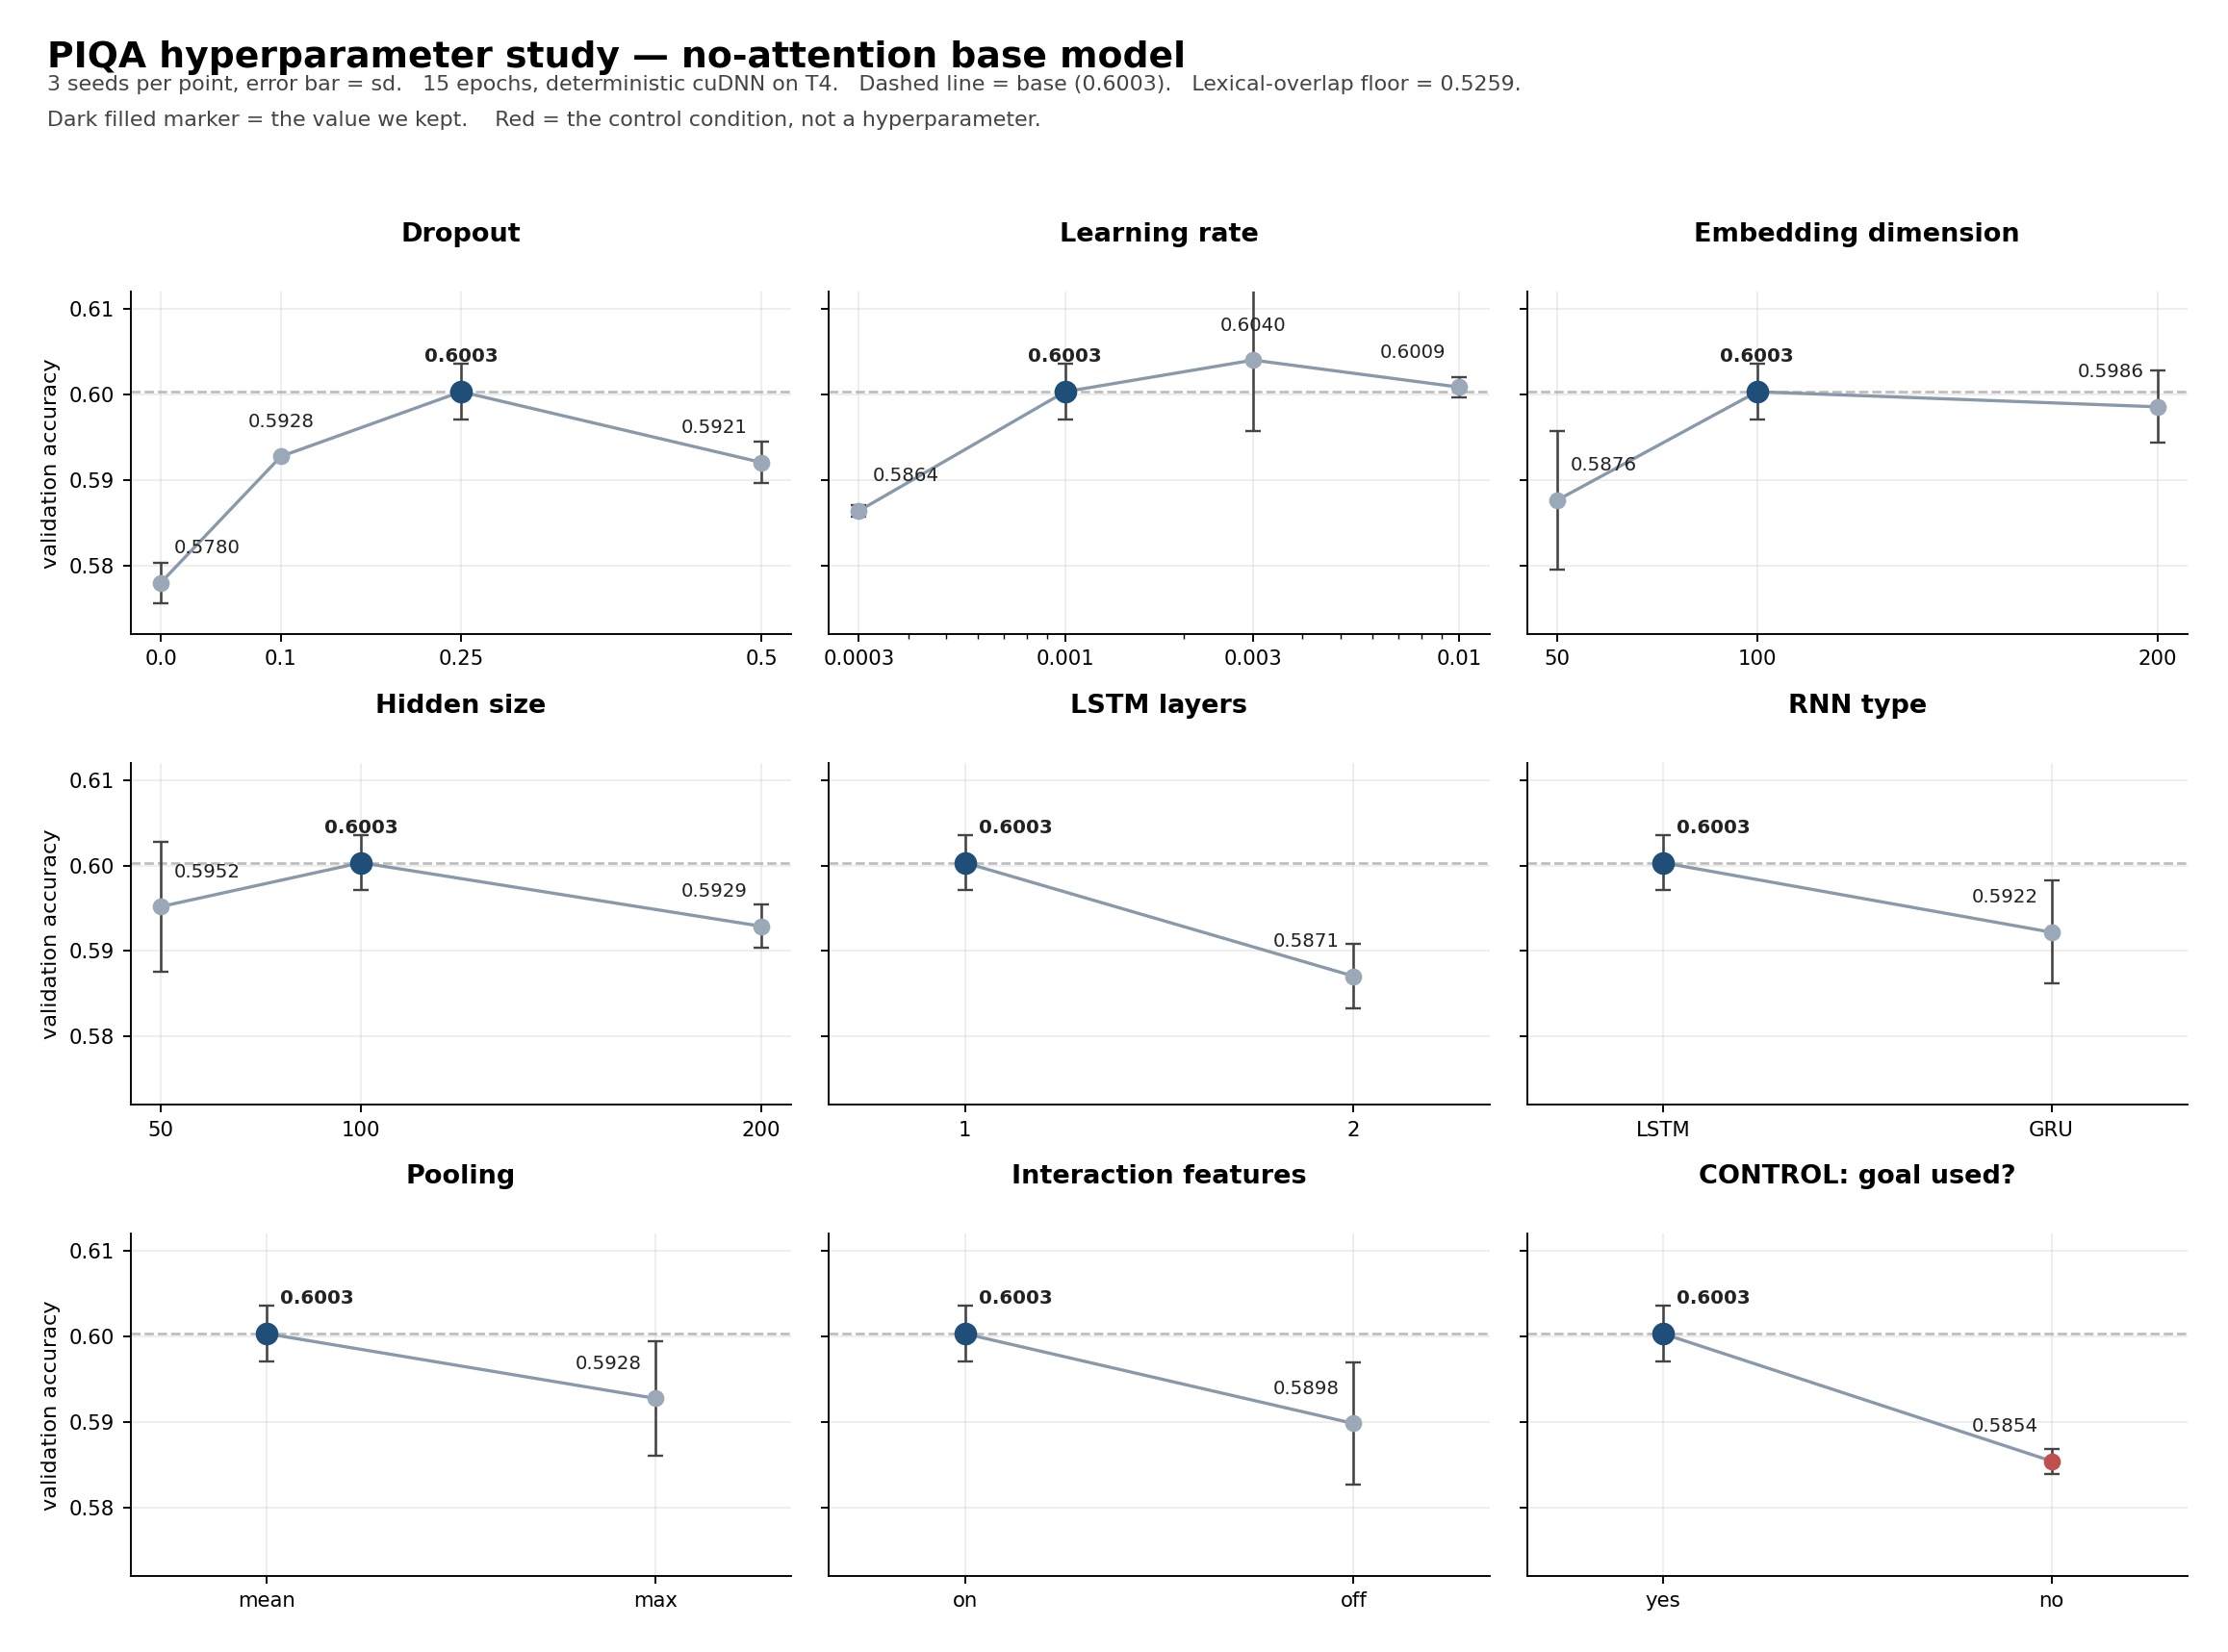

All runs: 3 seeds, 15 epochs, deterministic cuDNN on T4, same split.
Floor (lexical overlap) = 0.5259.  Base = **0.6003 ± 0.0032**, +0.0745 over floor.
Pooled seed sd across all configurations ≈ 0.005, so a gap below ~0.010 is not a real gap.

| hyperparameter | values tested | chosen | range | shape |
|---|---|---|---|---|
| **training** | | | | |
| dropout | 0 / 0.1 / **0.25** / 0.5 | 0.25 | 0.022 | inverted U, clear peak |
| learning rate | 0.0003 / **0.001** / 0.003 / 0.01 | 0.001 | 0.018 | floor below 0.001, flat above |
| epochs | 15, fixed | 15 | — | peak lands around epoch 12 |
| batch size | 32, not varied | 32 | — | — |
| **capacity** | | | | |
| embedding dim | 50 / **100** / 200 | 100 | 0.013 | elbow, 200 adds 86% params for nothing |
| hidden size | 50 / **100** / 200 | 100 | 0.007 | flat across the whole range |
| LSTM layers | **1** / 2 | 1 | 0.013 | monotone, 2 is worse (t = −3.78) |
| **structure** | | | | |
| RNN type | **LSTM** / GRU | LSTM | 0.008 | not distinguishable |
| pooling | **mean** / max | mean | 0.008 | not distinguishable |
| interaction features | **on** / off | on | 0.011 | favours on (t = −1.90, not significant) |

range = highest minus lowest mean across the values tested. It reflects how wide a range
we searched as much as how much the hyperparameter matters, so it is not an importance
ranking. 3 seeds per cell; pooled seed sd ≈ 0.005, so a gap below ~0.010 is not reliable.

### Control experiment (not a hyperparameter)

| | accuracy | vs base |
|---|---|---|
| goal used (base) | 0.6003 ± 0.0032 | — |
| **goal removed** | 0.5854 ± 0.0015 | **−0.0149, t = −5.93, significant** |

Decomposing the gain over the lexical floor: solution-only features contribute 0.0595,
the goal a further 0.0149, so about 20% of the model's advantage comes from reading the
goal. PIQA's known annotation artefacts are real but partial.

### What the study established

1. Four hyperparameters have measurable effects and four different shapes: dropout has a
   genuine optimum, learning rate has a floor, layers are monotone, embedding dimension
   has an elbow. Three (RNN type, pooling, hidden size) could not be distinguished from
   noise.
2. Configurations with reduced capacity (embedding 50, hidden 50) showed roughly twice the
   seed spread of the others (sd 0.008 vs 0.003), so the loss at small capacity comes
   partly from unstable optimisation, not only from the representational limit.
3. The model does use the goal, but most of its performance comes from the solutions alone.

### Methodological note

Fixing the random seed is not sufficient for reproducibility on GPU: cuDNN's LSTM backward
pass accumulates gradients non-deterministically, and identical seeds gave results
differing by up to 0.015. We enabled `cudnn.deterministic` and verified bit-identical
reproduction before collecting any number reported here. An earlier sweep run without it
reported a dropout effect in the opposite direction; that result was not reproducible and
is withdrawn.

---
# PART 6 — Handover notes for Ray

Everything below is settled. The attention section is yours.

---

## 1. Numbers you will need

| | |
|---|---|
| floor — best dumb baseline (word overlap with the goal) | **0.5259** |
| base — no-attention model, final settings | **0.6003 ± 0.0032** |
| base, the three seeds | `[0.6049, 0.5978, 0.5983]` |
| pooled seed sd across all 20+ configurations run so far | **≈ 0.005** |
| so: a gap below | **≈ 0.010 is not a real gap** |

```python
base_settings = {"attention_type"      : "none",
                 "use_cross_attention" : False,
                 "use_interaction"     : True,
                 "dropout_input"       : 0.25,
                 "dimension"           : 100,
                 "n_hidden_input"      : 100,
                 "num_layers_input"    : 1,
                 "pooling"             : "mean"}
# plus lr 0.001, batch 32, 15 epochs, seeds [0,1,2]
```

Every one of those values was chosen by a sweep — see PART 5. Please do not change them
while varying attention, or the comparison stops being controlled.

---

## 2. Protocol — do not change any of this

* **3 seeds** per configuration, report mean ± sd
* **15 epochs** for every run. The model peaks around epoch 12 and we keep the best epoch,
  so a different budget quietly inflates the score and the numbers stop being comparable.
* **same split**, `train_test_split(test_size=0.15, random_state=0, stratify=label)`
* **the test set is not touched until 13 October**, by anyone, for any reason
* **deterministic cuDNN stays on**. The two lines at the bottom of `set_seed` are not
  optional — see section 5.

---

## 3. The three attention functions — Step 6

All three live in one cell as plain functions, outside the model class, so you can edit
them without touching anything else. The class only calls them.

All three do the same three steps:


| | what gets scored | query | learnable params | switch |
|---|---|---|---|---|
| `attention_on_solution` | the 60 solution words | `W · goal_vector` (goal mode) or `pool_query` (self mode) | **40,000** / 200 | `attention_type` |
| `attention_on_goal` | the 20 goal words | `goal_query` | 200 | `goal_attention` |
| `cross_attention` | one solution against the other | none | **0** | `use_cross_attention` |

**Every function returns `(result, weights)`.** `forward` hands all the weights back in a
dict, so nothing in the model needs editing to plot anything:

```python
output, attention = model(goal, sol1, sol2)
attention["sol1_alpha"]   # (B, 60)        heat map over solution 1
attention["sol2_alpha"]   # (B, 60)
attention["goal_alpha"]   # (B, 20)  or None if goal_attention is off
attention["sol1_align"]   # (B, 60, 60)  or None if cross attention is off
attention["sol2_align"]   # (B, 60, 60)
```

---

## 4. How to run an experiment

```python
configuration_list = []

s = dict(base_settings); s["attention_type"] = "goal"
configuration_list.append(("goal attention", s))

s = dict(base_settings); s["attention_type"] = "self"
configuration_list.append(("self attention", s))

result = run_configurations(configuration_list)
```

To test against the base, add its seeds by hand and use `compare`:

```python
combined = {}
combined.update(result)
combined["base (no attention)"] = [0.6049, 0.5978, 0.5983]
compare(combined, "base (no attention)")
```

`compare` runs a Welch t-test. With 3 seeds the cutoff is **|t| > 4.3**, not 1.96.

---

## 5. Four things that will bite you

### a. Determinism is not automatic

cuDNN's LSTM backward pass accumulates gradients in a non-deterministic order, so the same
seed gives a different answer every run. We measured differences up to **0.015** — larger
than most of the effects in this study. The fix is already in `set_seed`:

```python
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
```

Verify it before trusting anything: train the same config twice and check the two numbers
are identical to six decimal places. Determinism holds only on the same GPU and the same
versions — ours is **Tesla T4, torch 2.11.0+cu130, cuDNN 92700**. If Colab gives you a
different card, your numbers will not line up with this file.

### b. `use_goal=False` is a master switch, not a normal ablation

When it is False the goal vector is zeroed, which makes the attention query zero, which
makes the attention weights uniform. So `use_goal=False` behaves exactly like
`attention_type="none"` no matter what the other switches say. Run that control once; do
not cross it with anything.

### c. The parameter count printed by `sum(p.numel())` is misleading

`W`, `pool_query` and `goal_query` are created every time, whichever switches are on. So
`attention_type="none"` and `attention_type="goal"` report the *same* total, even though
one of them is not using 40,000 of those parameters. Count only what is in use when you
report parameter counts in an ablation table — otherwise "which is better" gets confused
with "which is smaller", which is a real risk here (see 5d).

### d. Adding a parameter in the middle of `__init__` invalidates every earlier number

Initialisation consumes random numbers in order. Inserting a new `nn.Parameter` or
`nn.Linear` shifts the draw for every layer created after it, so the same seed produces a
different model. We lost a full batch of results to exactly this. **Add any new parameters
at the end of `__init__`.**

---

## 6. Results that are VOID — do not use them

An earlier batch of attention results (0.6039 / 0.6037 / 0.5994 / 0.5991 / 0.5988 /
0.5966 and friends) was collected before determinism was enabled, at 10 epochs, with a
different base. **None of it reproduces.** Ignore any table that quotes those numbers.

Also withdrawn: an early finding that "the goal contributes almost nothing". That was
measured on the void batch. The correct, reproducible measurement is in the next section.

---

## 7. One result you should know before you start

The control experiment has already been run properly:

| | accuracy | vs base |
|---|---|---|
| goal used (base) | 0.6003 ± 0.0032 | — |
| goal removed | 0.5854 ± 0.0015 | **−0.0149, t = −5.93, significant** |

**The goal carries real signal.** About 20% of the model's gain over the lexical floor
comes from reading it. That matters for you: goal-conditioned attention has something to
condition on, so it is a reasonable thing to build, not a dead end.

Please do not re-run this control — it costs 12 minutes and the answer is above.

---

## 8. For the attention analysis section of the report

The marking guide asks for visualisations plus analysis, with both successful and failed
predictions. A heat map on its own is the weak version of this. The strong version is a
number.

PIQA has no gold annotation of which words matter, so the stand-in is **the words that
differ between the two solutions** — on average only about 5 of them, often just one
(`weld` / `nail`, `butcher block oil` / `butcher knife oil`). Useful things to measure:

* how often the top-attended word is one of the differing words, against the chance rate
* whether that differs between correct and incorrect predictions
* `alpha.max()` per row, to show the attention is focused rather than collapsed to uniform
* how different `sol1_alpha` and `sol2_alpha` are from each other — the two solutions are
  near-duplicates, so this one is worth thinking about

Pick **short** examples for the figures. Solutions average 19 words but reach 88; a
heat map over a long one is unreadable.

---

## 9. Questions worth answering with your ablations

* Does any attention variant beat 0.6003 by more than 0.010?
* Does goal mode beat self mode? They differ by 40,000 parameters, so report both the
  accuracy and the parameter count.
* Does cross attention help, given that it has no parameters of its own and only widens
  the MLP input by 200?
* Under which variant, if any, does the goal become *more* useful than the 0.0149 above?

---

**Contact me before changing anything in PART 1–4.** The data pipeline, the metric and the
split have to stay fixed or none of our numbers can be put in the same table.